# Validation against Xu & Froment (1989, Part II) Fig. 3

Digitised curves of Fig. 3 (p. 101) are compared with the 1-D tube model (`rdt.reactor1d`) using the digitised
outer-wall temperature as the boundary condition over the heated length (0-11.12 m) and an adiabatic tail to 12 m.
Two-stage bounded least-squares calibration: (A) bed voidage and particle diameter on the pressure curve,
(B) one effectiveness-factor multiplier on `x_CH4` and `T_gas`. Latham's inlet variant (eta = 0.05 in the first
10 % of the length) is also tried. Results are written to `data/literature_validation/xf1989_fit.yaml`.
The left-axis correction `x = raw * (1 + zeta)`, zeta = 0.056, is an assumption to be confirmed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

from rdt import validate_xf1989 as vx

tidy = vx.load_tidy()
cv = vx.curves(tidy)
print("rows per curve:", tidy.groupby("curve").size().to_dict())
print("\nSanity checks on the digitised data")
sanity = vx.sanity_checks(tidy)
for k, (v, (lo, hi), ok) in sanity.items():
    print(f"  {k:18s} = {v:9.3f}   expected {lo}-{hi}   {'OK' if ok else 'FLAG'}")
print("\nOther observations (not corrected):")
for c in ("T_gas", "T_wall_inner", "x_CH4", "x_CO2"):
    z, v = cv[c]; print(f"  {c:13s} first digitised point z={z[0]:.3f}: {v[0]:.4f}")
print("  Table 2 inlet T0 = 793.15 K; digitised T_gas starts ~29 K lower. Conversions start at ~0.06, not 0.")


rows per curve: {'T_gas': 386, 'T_wall_inner': 261, 'T_wall_outer': 118, 'p_t': 462, 'x_CH4': 457, 'x_CO2': 422}

Sanity checks on the digitised data
  T_wall_outer_z0    =  1012.877   expected 1000.0-1040.0   OK
  T_wall_outer_max   =  1176.215   expected 1160.0-1190.0   OK
  p_t_z0             =    28.959   expected 28.5-29.5   OK
  p_t_z11.5          =    25.761   expected 25.0-26.0   OK
  x_CH4_z11.12       =     0.589   expected 0.55-0.65   OK

Other observations (not corrected):
  T_gas         first digitised point z=0.009: 763.9571
  T_wall_inner  first digitised point z=0.005: 984.3139
  x_CH4         first digitised point z=0.008: 0.0601
  x_CO2         first digitised point z=0.011: 0.0581
  Table 2 inlet T0 = 793.15 K; digitised T_gas starts ~29 K lower. Conversions start at ~0.06, not 0.


In [2]:
wall = vx.wall_from_digitised(tidy)
BASE_VOID, BASE_DP = 0.6, 9.24e-3          # current reactor1d defaults for the XF bed

def show(m):
    for c, d in m.items():
        print(f"   {c:13s} RMSE = {d['rmse']:8.4f} {d['unit']:3s}  max|err| = {d['max_abs']:8.4f}  bias = {d['mean_bias']:+8.4f}  (n={d['n']})")

base = vx.run(BASE_VOID, BASE_DP, wall)
m_base = vx.metrics(base, cv)
print("BASELINE (voidage 0.6, d_p 9.24 mm, eta 0.1):"); show(m_base)
out_base = vx.outlet_summary(base)
print({k: round(v, 4) for k, v in out_base.items()})


BASELINE (voidage 0.6, d_p 9.24 mm, eta 0.1):
   x_CH4         RMSE =   0.1465 -    max|err| =   0.2031  bias =  +0.1241  (n=457)
   x_CO2         RMSE =   0.0300 -    max|err| =   0.0532  bias =  +0.0011  (n=422)
   T_gas         RMSE =  73.2598 K    max|err| =  92.2462  bias = +70.3359  (n=386)
   T_wall_inner  RMSE =  37.7032 K    max|err| =  92.2399  bias =  -2.3633  (n=261)
   p_t           RMSE =   0.6991 bar  max|err| =   1.5031  bias =  +0.5501  (n=462)
{'z_m': 12.0, 'T_K': 1111.3154, 'P_bar': 27.1152, 'conversion_CH4': 0.7889, 'yield_CO2': 0.3106, 'X_H2_dry': 0.6965, 'T_wall_outer_K': 1111.3154, 'T_wall_inner_K': 1111.3154, 'dT_approach_I_K': 0.0454, 'conversion_CH4_at_11.12': 0.7857, 'T_K_at_11.12': 1113.874, 'P_bar_at_11.12': 27.2939, 'dP_bar_total': 1.8848, 'T_min_K': 777.2843, 'z_Tmin_m': 0.1, 'inlet_dip_K': 15.8657}


In [3]:
A = vx.calibrate_stage_a(cv, wall)
print("Stage A (p_t only):", {k: A[k] for k in ("voidage", "d_p_m", "n_runs", "at_bound", "message")})
B = vx.calibrate_stage_b(cv, wall, A["voidage"], A["d_p_m"])
print("Stage B (x_CH4 + T_gas):", {k: B[k] for k in ("eta_multiplier", "n_runs", "at_bound", "message")})
fit = vx.run(A["voidage"], A["d_p_m"], wall, eta=vx.eta_spec(B["eta_multiplier"]))
m_fit = vx.metrics(fit, cv)
print("FITTED:"); show(m_fit)
out_fit = vx.outlet_summary(fit)
print({k: round(v, 4) for k, v in out_fit.items()})

BL = vx.calibrate_stage_b(cv, wall, A["voidage"], A["d_p_m"], latham=True)
fitL = vx.run(A["voidage"], A["d_p_m"], wall, eta=vx.eta_spec(BL["eta_multiplier"], latham=True))
m_fitL = vx.metrics(fitL, cv); out_fitL = vx.outlet_summary(fitL)
lat_base = vx.run(BASE_VOID, BASE_DP, wall, eta=vx.eta_spec(1.0, latham=True))
print("\nLatham inlet variant (eta 0.05 for z < 1.2 m):")
print(f"   multiplier {BL['eta_multiplier']:.3f}; inlet dip baseline-bed eta 0.1: {out_base['inlet_dip_K']:.1f} K, "
      f"with Latham variant: {vx.outlet_summary(lat_base)['inlet_dip_K']:.1f} K; fitted+Latham: {out_fitL['inlet_dip_K']:.1f} K")
show(m_fitL)


Stage A (p_t only): {'voidage': 0.526070573791837, 'd_p_m': 0.009439519780359574, 'n_runs': 74, 'at_bound': False, 'message': '`xtol` termination condition is satisfied.'}


Stage B (x_CH4 + T_gas): {'eta_multiplier': 0.20000000000206433, 'n_runs': 12, 'at_bound': True, 'message': '`gtol` termination condition is satisfied.'}
FITTED:
   x_CH4         RMSE =   0.1164 -    max|err| =   0.1723  bias =  +0.0862  (n=457)
   x_CO2         RMSE =   0.0260 -    max|err| =   0.0561  bias =  -0.0150  (n=422)
   T_gas         RMSE =  75.0836 K    max|err| =  82.5078  bias = +73.8056  (n=386)
   T_wall_inner  RMSE =  34.4461 K    max|err| =  85.2650  bias =  -2.1548  (n=261)
   p_t           RMSE =   0.0505 bar  max|err| =   0.1447  bias =  +0.0022  (n=462)
{'z_m': 12.0, 'T_K': 1099.4998, 'P_bar': 25.7075, 'conversion_CH4': 0.7709, 'yield_CO2': 0.3148, 'X_H2_dry': 0.6927, 'T_wall_outer_K': 1099.4998, 'T_wall_inner_K': 1099.4998, 'dT_approach_I_K': 1.039, 'conversion_CH4_at_11.12': 0.7584, 'T_K_at_11.12': 1110.2137, 'P_bar_at_11.12': 26.0265, 'dP_bar_total': 3.2925, 'T_min_K': 790.7101, 'z_Tmin_m': 0.05, 'inlet_dip_K': 2.4399}



Latham inlet variant (eta 0.05 for z < 1.2 m):
   multiplier 0.200; inlet dip baseline-bed eta 0.1: 15.9 K, with Latham variant: 8.5 K; fitted+Latham: 0.0 K
   x_CH4         RMSE =   0.1153 -    max|err| =   0.1709  bias =  +0.0805  (n=457)
   x_CO2         RMSE =   0.0293 -    max|err| =   0.0628  bias =  -0.0180  (n=422)
   T_gas         RMSE =  74.8939 K    max|err| =  81.8304  bias = +74.0682  (n=386)
   T_wall_inner  RMSE =  34.1425 K    max|err| =  85.0037  bias =  -2.1490  (n=261)
   p_t           RMSE =   0.0517 bar  max|err| =   0.1509  bias =  +0.0048  (n=462)


In [4]:
# Diagnostic (not part of the requested calibration): sensitivity to the gas-side
# heat-transfer multiplier f_htg with the stage-A bed and eta = 0.1.
diag = {}
for f in (1.0, 0.7, 0.5, 0.4, 0.3):
    r = vx.run(A["voidage"], A["d_p_m"], wall, eta=vx.eta_spec(1.0), f_htg=f)
    m = vx.metrics(r, cv)
    diag[f] = {"T_gas_rmse": m["T_gas"]["rmse"], "T_gas_bias": m["T_gas"]["mean_bias"],
               "x_CH4_rmse": m["x_CH4"]["rmse"], "x_CH4_bias": m["x_CH4"]["mean_bias"],
               "T_wall_inner_rmse": m["T_wall_inner"]["rmse"], "T_wall_inner_bias": m["T_wall_inner"]["mean_bias"],
               "conversion_at_11.12": float(np.interp(11.12, r.z, r.conversion_CH4)), "T_at_11.12": float(np.interp(11.12, r.z, r.T))}
    print(f"f_htg={f:.1f}: " + ", ".join(f"{k}={v:8.3f}" for k, v in diag[f].items()))


f_htg=1.0: T_gas_rmse=  73.065, T_gas_bias=  70.007, x_CH4_rmse=   0.153, x_CH4_bias=   0.130, T_wall_inner_rmse=  37.783, T_wall_inner_bias=  -2.746, conversion_at_11.12=   0.796, T_at_11.12=1112.999


f_htg=0.7: T_gas_rmse=  51.344, T_gas_bias=  48.574, x_CH4_rmse=   0.105, x_CH4_bias=   0.084, T_wall_inner_rmse=  29.365, T_wall_inner_bias=  -3.249, conversion_at_11.12=   0.743, T_at_11.12=1090.406


f_htg=0.5: T_gas_rmse=  27.566, T_gas_bias=  25.390, x_CH4_rmse=   0.054, x_CH4_bias=   0.035, T_wall_inner_rmse=  20.948, T_wall_inner_bias=  -3.780, conversion_at_11.12=   0.674, T_at_11.12=1063.221


f_htg=0.4: T_gas_rmse=  10.751, T_gas_bias=   8.911, x_CH4_rmse=   0.023, x_CH4_bias=   0.000, T_wall_inner_rmse=  16.483, T_wall_inner_bias=  -4.177, conversion_at_11.12=   0.619, T_at_11.12=1042.467


f_htg=0.3: T_gas_rmse=  13.475, T_gas_bias= -12.971, x_CH4_rmse=   0.044, x_CH4_bias=  -0.044, T_wall_inner_rmse=  15.535, T_wall_inner_bias=  -4.814, conversion_at_11.12=   0.543, T_at_11.12=1013.203


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig03_validation_xf1989.png


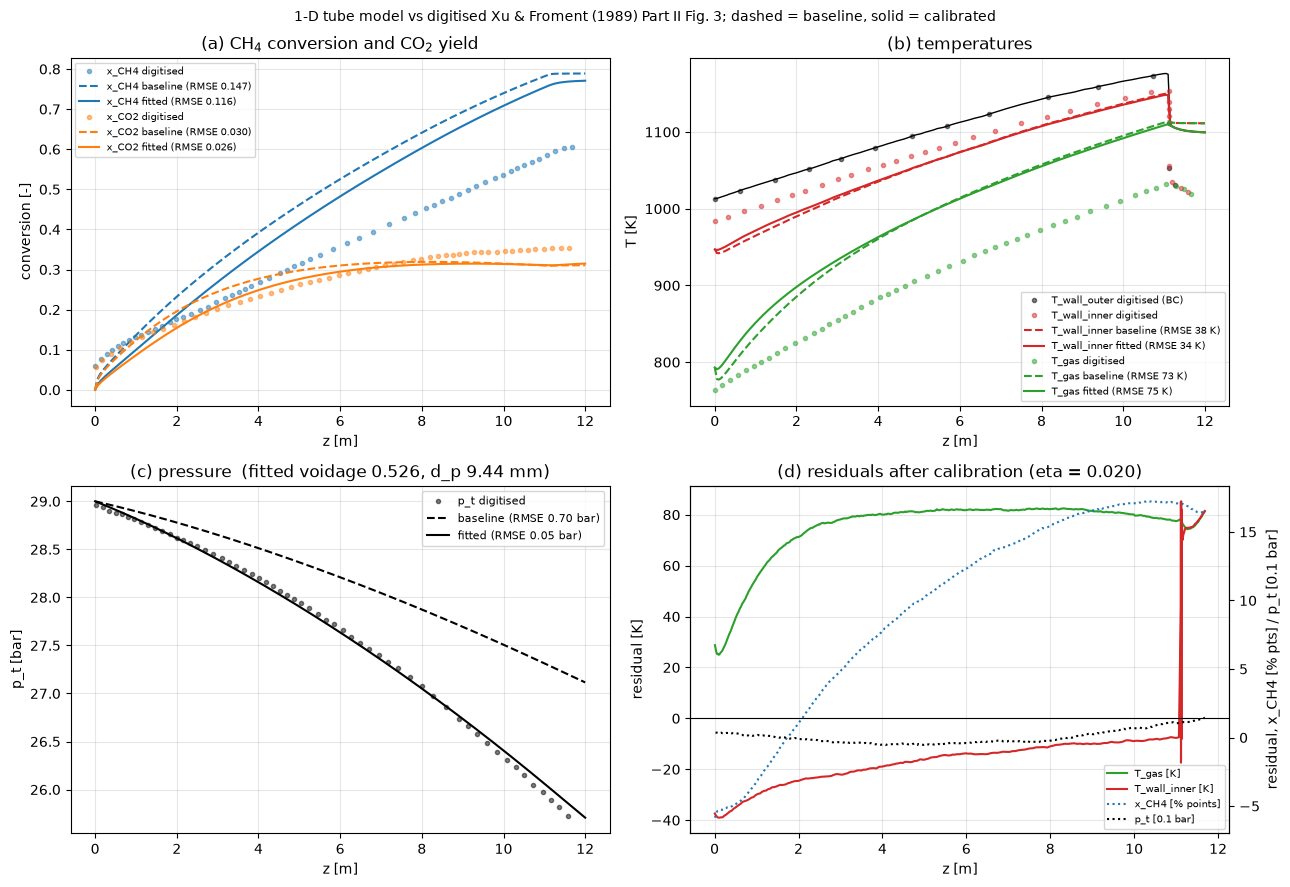

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
mk = dict(ls="none", marker="o", ms=3, alpha=0.5)
sub = 8  # marker subsampling

def data(c):
    z, v = cv[c]; return z[::sub], v[::sub]

# (a) conversions
a = ax[0, 0]
for c, col in (("x_CH4", "C0"), ("x_CO2", "C1")):
    z, v = data(c); a.plot(z, v, color=col, label=f"{c} digitised", **mk)
    a.plot(base.z, vx.model_curve(base, c, base.z), color=col, ls="--", label=f"{c} baseline (RMSE {m_base[c]['rmse']:.3f})")
    a.plot(fit.z, vx.model_curve(fit, c, fit.z), color=col, ls="-", label=f"{c} fitted (RMSE {m_fit[c]['rmse']:.3f})")
a.set_xlabel("z [m]"); a.set_ylabel("conversion [-]"); a.set_title("(a) CH$_4$ conversion and CO$_2$ yield"); a.grid(alpha=0.3); a.legend(fontsize=7)

# (b) temperatures
b = ax[0, 1]
z, v = data("T_wall_outer"); b.plot(z, v, color="k", label="T_wall_outer digitised (BC)", **mk)
b.plot(fit.z, fit.T_wall_outer, color="k", lw=1)
for c, col in (("T_wall_inner", "C3"), ("T_gas", "C2")):
    z, v = data(c); b.plot(z, v, color=col, label=f"{c} digitised", **mk)
    b.plot(base.z, vx.model_curve(base, c, base.z), color=col, ls="--", label=f"{c} baseline (RMSE {m_base[c]['rmse']:.0f} K)")
    b.plot(fit.z, vx.model_curve(fit, c, fit.z), color=col, ls="-", label=f"{c} fitted (RMSE {m_fit[c]['rmse']:.0f} K)")
b.set_xlabel("z [m]"); b.set_ylabel("T [K]"); b.set_title("(b) temperatures"); b.grid(alpha=0.3); b.legend(fontsize=7)

# (c) pressure
c_ = ax[1, 0]
z, v = data("p_t"); c_.plot(z, v, color="k", label="p_t digitised", **mk)
c_.plot(base.z, base.P, "k--", label=f"baseline (RMSE {m_base['p_t']['rmse']:.2f} bar)")
c_.plot(fit.z, fit.P, "k-", label=f"fitted (RMSE {m_fit['p_t']['rmse']:.2f} bar)")
c_.set_xlabel("z [m]"); c_.set_ylabel("p_t [bar]"); c_.set_title(f"(c) pressure  (fitted voidage {A['voidage']:.3f}, d_p {1e3*A['d_p_m']:.2f} mm)"); c_.grid(alpha=0.3); c_.legend(fontsize=8)

# (d) residuals, fitted model minus data
d = ax[1, 1]
for c, col in (("T_gas", "C2"), ("T_wall_inner", "C3")):
    z, v = cv[c]; d.plot(z, vx.model_curve(fit, c, z) - v, color=col, label=f"{c} [K]")
d.axhline(0, color="k", lw=0.8); d.set_xlabel("z [m]"); d.set_ylabel("residual [K]")
d2 = d.twinx()
z, v = cv["x_CH4"]; d2.plot(z, 100 * (vx.model_curve(fit, "x_CH4", z) - v), color="C0", ls=":", label="x_CH4 [% points]")
z, v = cv["p_t"]; d2.plot(z, 10 * (vx.model_curve(fit, "p_t", z) - v), color="k", ls=":", label="p_t [0.1 bar]")
d2.set_ylabel("residual, x_CH4 [% pts] / p_t [0.1 bar]")
h1, l1 = d.get_legend_handles_labels(); h2, l2 = d2.get_legend_handles_labels(); d.legend(h1 + h2, l1 + l2, fontsize=7)
d.set_title(f"(d) residuals after calibration (eta = {0.1*B['eta_multiplier']:.3f})"); d.grid(alpha=0.3)

fig.suptitle("1-D tube model vs digitised Xu & Froment (1989) Part II Fig. 3; dashed = baseline, solid = calibrated", fontsize=10)
fig.tight_layout()
out = Path("..") / "paper" / "figures" / "fig03_validation_xf1989.png"
fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


In [6]:
def py(o):
    if isinstance(o, dict): return {str(k): py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [py(v) for v in o]
    if isinstance(o, (np.floating, np.integer)): return o.item()
    if isinstance(o, np.bool_): return bool(o)
    return o

doc = {
    "source": "Xu & Froment (1989) Part II, AIChE J. 35:97-103, Fig. 3 (p. 101), digitised with WebPlotDigitizer",
    "data_file": "data/literature_validation/digitized/xf1989_fig3_tidy.csv",
    "data_notes": [
        "conversion curves corrected by (1+zeta), zeta = CO2/CH4 = 0.056 (ASSUMPTION, to be confirmed)",
        "digitised T_gas starts at ~764 K at z~0 although Table 2 gives T0 = 793.15 K (not corrected)",
        "digitised conversions start at ~0.06 at z~0, not at 0 (not corrected)",
        "T_wall_outer beyond 11.12 m falls to the gas temperature: tail treated as adiabatic",
    ],
    "sanity_checks": py({k: {"value": v, "range": list(r), "ok": ok} for k, (v, r, ok) in sanity.items()}),
    "boundary_condition": "PCHIP of digitised T_wall_outer for 0 <= z <= 11.12 m; adiabatic (U = 0) for 11.12 < z <= 12 m",
    "compared_on": "digitised z grid of each curve (model interpolated linearly onto it)",
    "objective_definition": (
        "least_squares (scipy, trf, bounded) on residuals r_c(z_k) = (model - data)/(max(data_c) - min(data_c))/sqrt(n_c) "
        "for each compared curve c on its digitised grid; stage A: c in {p_t}, parameters voidage in [0.35, 0.60], d_p in [4, 12] mm; "
        "stage B: c in {x_CH4, T_gas}, parameter m in [0.2, 2.0] with eta_1 = eta_2 = eta_3 = 0.1 m, stage-A values fixed"
    ),
    "baseline": {"parameters": {"voidage": BASE_VOID, "d_p_m": BASE_DP, "eta": [0.1, 0.1, 0.1], "f_htg": 1.0},
                 "metrics": py(m_base), "outlet": py(out_base)},
    "fitted": {"stage_A": py(A), "stage_B": py(B),
               "parameters": {"voidage": A["voidage"], "d_p_m": A["d_p_m"], "eta": B["eta_values"], "f_htg": 1.0},
               "metrics": py(m_fit), "outlet": py(out_fit)},
    "latham_inlet_variant": {"description": "eta = 0.05*m for z < 1.2 m (10 % of 12 m), 0.1*m elsewhere",
                             "stage_B": py(BL), "metrics": py(m_fitL), "outlet": py(out_fitL),
                             "inlet_dip_K_baseline_bed_eta0.1": py(out_base["inlet_dip_K"]),
                             "inlet_dip_K_baseline_bed_latham": py(vx.outlet_summary(lat_base)["inlet_dip_K"]),
                             "removes_inlet_dip": bool(out_fitL["inlet_dip_K"] < 0.5)},
    "diagnostics_f_htg_sweep": {"description": "stage-A bed, eta = 0.1, Leva-Grummer multiplier f_htg varied (not fitted)",
                                "results": py({str(k): v for k, v in diag.items()})},
}
with open(Path("..") / "data" / "literature_validation" / "xf1989_fit.yaml", "w") as f:
    yaml.safe_dump(doc, f, sort_keys=False, default_flow_style=False, width=120)
print("wrote xf1989_fit.yaml")


wrote xf1989_fit.yaml
